### Clustering

In [17]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [18]:
df = pd.read_csv("Airbnb_NYC_2019_VF.csv")
X = df[['price', 'minimum_nights']]

##### Método do joelho

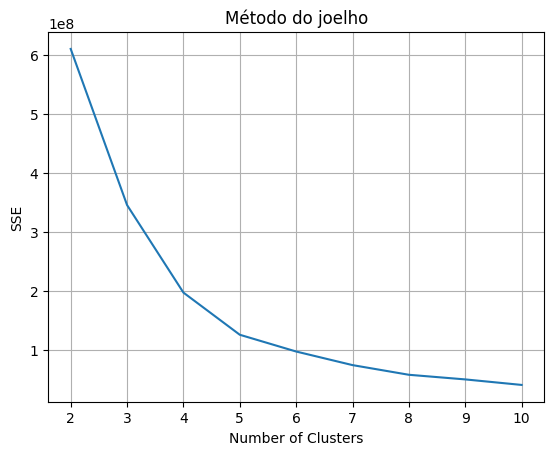

In [ ]:
sse = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=12345)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(range(2, 11), sse)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Método do joelho")
plt.grid()
plt.show()

Conclusão:
- Os melhores pontos são as "extremidades" do joelho.
- Neste caso, corresponde ao número de clusters igual a 3, 4 e 5.

##### Métrica Silhouette

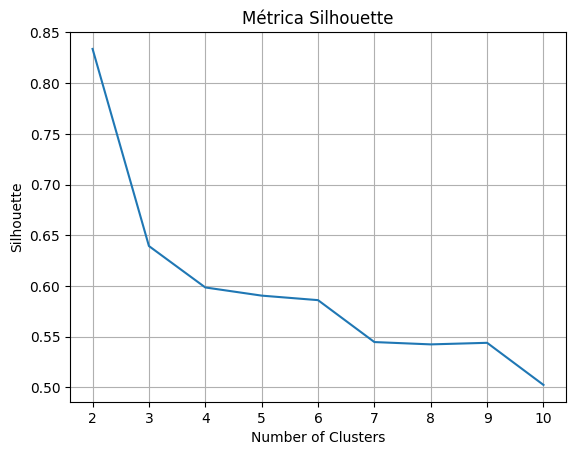

In [ ]:
silhouette = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=12345)
    clusters = kmeans.fit_predict(X)
    ss = silhouette_score(X, clusters)
    silhouette.append(ss)

plt.plot(range(2, 11), silhouette)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette")
plt.title("Métrica Silhouette")
plt.grid()
plt.show()

Conclusões:
- Esta métrica pode tomar valores entre 1 (melhor) e -1 (pior).
- Neste caso, o número de clusters igual a 2 obtém o melhor valor de Silhouette. 

In [ ]:
colors = {
    0: "#4B0082",
    1: "#8A2BE2",
    2: "#AA6FF5",
    3: "#4169E1",    
    4: "#3399FF", 
    5: "#99CCFF", 
    6: "#FF1493", 
    7: "#FF66B2", 
    8: "#FF99CC"}

##### Segmentação com 2 clusters

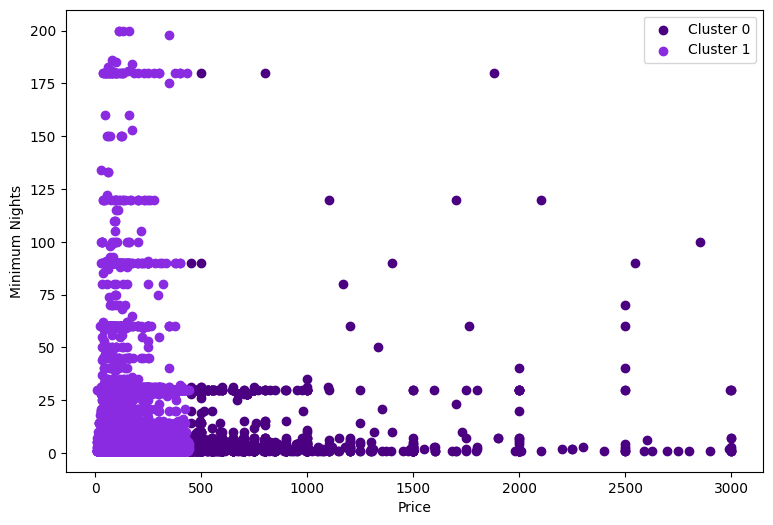

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=12345)
clusters = kmeans.fit_predict(X)
X["cl"] = clusters
X.sort_values(by="cl", inplace=True)

clusters = X.cl.unique()

plt.figure(figsize=(9, 6))
for cluster in clusters:
    Xcluster = X.query(f"cl == {cluster}")
    plt.scatter(
        Xcluster["price"],
        Xcluster["minimum_nights"],
        color=colors[cluster],
        label=f"Cluster {cluster}",
    )

plt.xlabel("Price")
plt.ylabel("Minimum Nights")
plt.legend()
plt.show()

##### Segmentação com 3 clusters

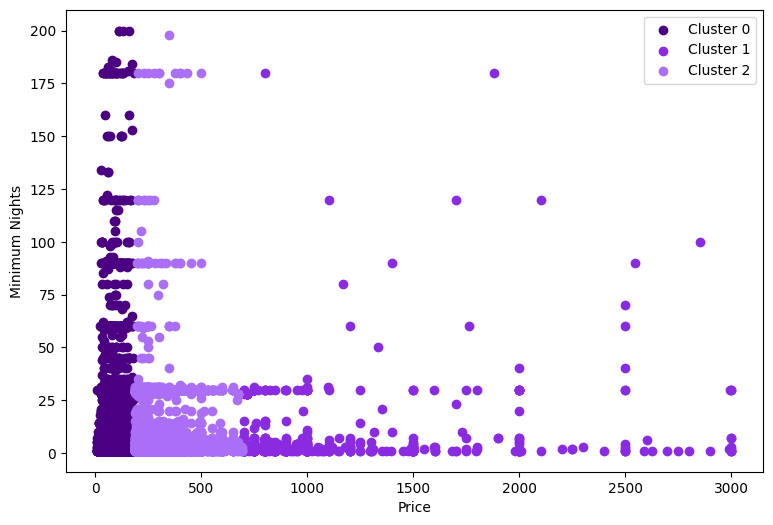

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=12345)
clusters = kmeans.fit_predict(X)
X["cl"] = clusters
X.sort_values(by="cl", inplace=True)

clusters = X.cl.unique()

plt.figure(figsize=(9, 6))
for cluster in clusters:
    Xcluster = X.query(f"cl == {cluster}")
    plt.scatter(
        Xcluster["price"],
        Xcluster["minimum_nights"],
        color=colors[cluster],
        label=f"Cluster {cluster}",
    )

plt.xlabel("Price")
plt.ylabel("Minimum Nights")
plt.legend()
plt.show()

### Análise com 2 clusters

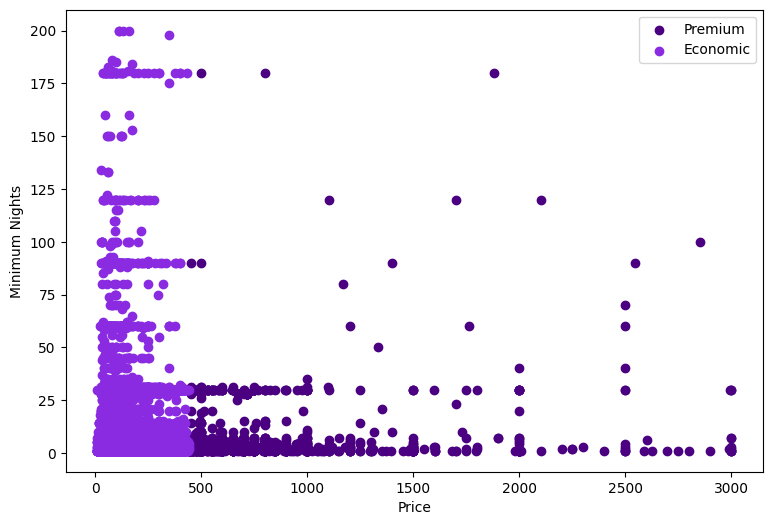

In [19]:
kmeans = KMeans(n_clusters=2, random_state=12345)
clusters = kmeans.fit_predict(X)

X['cluster'] = clusters

X.sort_values(by="cluster", inplace=True)

clusters = X.cluster.unique()

colors = {0: "#4B0082", 1: "#8A2BE2"}

plt.figure(figsize=(9, 6))

labels = {0: "Premium", 1: "Economic"}
for cluster in clusters:
    Xcluster = X.query(f"cluster == {cluster}")
    plt.scatter(
        Xcluster["price"],
        Xcluster["minimum_nights"],
        color=colors[cluster],
        label=labels[cluster]
    )

plt.xlabel("Price")
plt.ylabel("Minimum Nights")
plt.legend()
plt.show()

##### Gráficos de dispersão do custo total por mínimo de noites

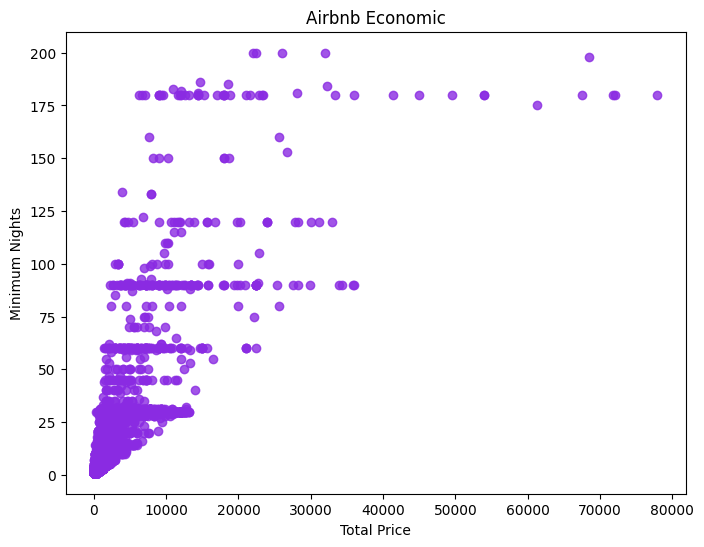

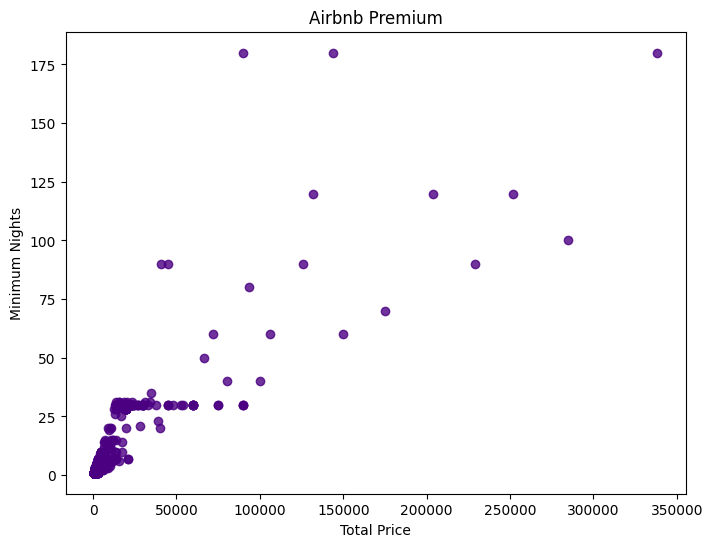

In [20]:
centroides = kmeans.cluster_centers_

price_cluster_0 = centroides[0][0]
price_cluster_1 = centroides[1][0]
limit_price = (price_cluster_0 + price_cluster_1) / 2

df_economic = df[df['price'] <= limit_price]
df_premium = df[df['price'] > limit_price]

df_economic['total_cost'] = df_economic['price'] * df_economic['minimum_nights']
df_premium['total_cost'] = df_premium['price'] * df_premium['minimum_nights']

plt.figure(figsize=(8, 6))
plt.scatter(df_economic['total_cost'], df_economic['minimum_nights'], alpha=0.8, color='#8A2BE2')
plt.title('Airbnb Economic')
plt.xlabel('Total Price')
plt.ylabel('Minimum Nights')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df_premium['total_cost'], df_premium['minimum_nights'], alpha=0.8, color='#4B0082')
plt.title('Airbnb Premium')
plt.xlabel('Total Price')
plt.ylabel('Minimum Nights')
plt.show()

##### Silhouette Score

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clusters = kmeans.fit_predict(X_scaled)

float(silhouette_score(X_scaled, clusters))

0.8541170720796853